# Práctica 1 - Procesamiento del corpus

El notebook sigue el orden de la rúbrica. Los archivos `.txt` del corpus son la fuente original y no se sobrescriben durante el preprocesamiento.

In [30]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
CORPUS_DIR = ROOT / "corpus"
METADATA_PATH = CORPUS_DIR / "metadata.csv"
metadata = pd.read_csv(METADATA_PATH)
metadata.head()

,doc_id,label,source_type,source_name,url,title,date,n_words,topic,file,original_id
0,ds_falso_0001,0,dataset,fuente2_kaggle,NaN,El órgano que fiscaliza al Gobierno andaluz de...,NaN,58,politica,Falso/ds_falso_0001.txt,ID
1,ds_falso_0002,0,dataset,fuente2_kaggle,NaN,PP pide a Cristina Narbona igualar los permiso...,NaN,50,politica,Falso/ds_falso_0002.txt,ID
2,ds_falso_0003,0,dataset,fuente2_kaggle,NaN,Cristina Narbona rebaja las hipótesis electora...,NaN,49,politica,Falso/ds_falso_0003.txt,ID
3,ds_falso_0004,0,dataset,fuente2_kaggle,NaN,"Carrero Blanco, elegida candidata del Iniciati...",NaN,47,politica,Falso/ds_falso_0004.txt,ID
4,ds_falso_0005,0,dataset,fuente2_kaggle,NaN,Diego Cañamero pide aprobar ya los presupuesto...,NaN,40,politica,Falso/ds_falso_0005.txt,ID


## 1. Creación y caracterización del corpus

El corpus definitivo contiene 5.300 documentos: 5.000 del dataset de Kaggle y 300 obtenidos mediante web scraping. La generación se realiza con `src/get_corpus_dataset.py` y `src/scrape_corpus.py`; cada script conserva los archivos de la otra fuente.

In [31]:
metadata["label_name"] = metadata["label"].map({0: "Falso", 1: "Verdad"})
metadata.groupby(["source_name", "label_name"]).size().unstack(fill_value=0)

label_name,Falso,Verdad
source_name,,
bbc_mundo,0,150
fuente2_kaggle,2500,2500
newtral,150,0


In [32]:
metrics = (
    metadata.groupby("source_name")["n_words"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        min="min",
        max="max",
        q25=lambda values: values.quantile(0.25),
        q50=lambda values: values.quantile(0.50),
        q75=lambda values: values.quantile(0.75),
        sum="sum",
    )
    .rename(columns={"count": "Count", "mean": "Mean", "std": "Std", "min": "Min", "max": "Max", "q25": "Q25", "q50": "Q50", "q75": "Q75", "sum": "Sum"})
    .round(2)
)
metrics

,Count,Mean,Std,Min,Max,Q25,Q50,Q75,Sum
source_name,,,,,,,,,
bbc_mundo,150,1176.32,822.18,61,3940,591.5,1058.5,1651.25,176448
fuente2_kaggle,5000,54.20,15.78,20,177,44.0,53.0,62.00,271012
newtral,150,753.59,894.53,220,10762,471.5,608.5,806.50,113039


In [33]:
assert len(metadata) == 5300
assert metadata["label"].value_counts().to_dict() == {0: 2650, 1: 2650}
assert metadata["source_name"].value_counts().to_dict() == {"fuente2_kaggle": 5000, "newtral": 150, "bbc_mundo": 150}
assert all((CORPUS_DIR / row.file).exists() for row in metadata.itertuples())
print("Corpus válido: 5.300 documentos.")

Corpus válido: 5.300 documentos.


## 2. Preprocesamiento

Esta fase se ejecuta después de crear el corpus. Incluye minúsculas, eliminación de tildes, números, URLs, saltos de línea, HTML, puntuación y emoticones. El resultado se guarda en una columna nueva para conservar el texto crudo.

In [34]:
from src.preprocess import clean_text, preprocess_dataframe

# Carga explícita del texto original desde los TXT.
metadata["text"] = metadata["file"].map(
    lambda relative_path: (CORPUS_DIR / relative_path).read_text(encoding="utf-8")
)
processed = preprocess_dataframe(metadata, text_column="text", output_column="clean_text")
processed[["doc_id", "label_name", "text", "clean_text"]].head(3)

,doc_id,label_name,text,clean_text
0,ds_falso_0001,Falso,El órgano que fiscaliza al Gobierno andaluz de...,el organo que fiscaliza al gobierno andaluz de...
1,ds_falso_0002,Falso,PP pide a Cristina Narbona igualar los permiso...,pp pide a cristina narbona igualar los permiso...
2,ds_falso_0003,Falso,Cristina Narbona rebaja las hipótesis electora...,cristina narbona rebaja las hipotesis electora...


In [35]:
# Verificación de que el preprocesamiento no sobrescribió los archivos fuente.
assert metadata["text"].str.len().sum() > processed["clean_text"].str.len().sum()
assert processed["clean_text"].map(lambda value: value == value.lower()).all()
assert not processed["clean_text"].str.contains(r"https?://|www\.", regex=True).any()
print("Preprocesamiento aplicado sobre una copia en memoria.")

Preprocesamiento aplicado sobre una copia en memoria.


## 3. Análisis lingüístico mediante POS Tagging

Se procesa cada documento con el modelo español `es_core_news_sm`. El análisis se realiza por separado para noticias verdaderas (`label=1`) y falsas (`label=0`). Las frecuencias relativas de la tabla se calculan sobre el total de tokens pertenecientes a las cinco categorías POS exigidas, por lo que cada clase suma 100%.

In [36]:
from src.pos_ner import (
    load_spanish_model,
    analyze_pos,
    comparative_table,
    top_words,
    plot_pos_distribution,
    save_pos_results,
)

nlp = load_spanish_model("es_core_news_sm")
pos_counts, word_counts = analyze_pos(
    metadata,
    nlp,
    text_column="text",
    label_column="label",
)
pos_table = comparative_table(pos_counts)
pos_table

,Verdaderas (cantidad),Verdaderas (%),Falsas (cantidad),Falsas (%)
POS,,,,
ADJ,20893.0,14.95,16293.0,15.06
ADV,9896.0,7.08,6589.0,6.09
NOUN,63003.0,45.08,51182.0,47.31
PRON,14407.0,10.31,9499.0,8.78
VERB,31572.0,22.59,24617.0,22.76


In [37]:
# Sumar la columna Verdaderas (%) del DataFrame pos_table
print(pos_table['Verdaderas (%)'].sum())

100.01


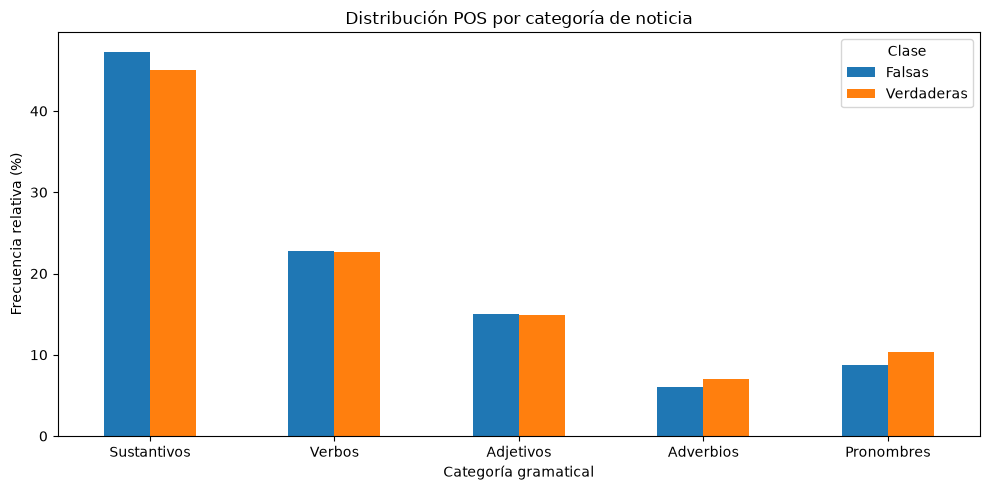

In [38]:
import matplotlib.pyplot as plt

pos_figure = plot_pos_distribution(pos_counts)
display(pos_figure)
RESULTS_POS_DIR = ROOT / "results" / "pos_ner"
RESULTS_POS_DIR.mkdir(parents=True, exist_ok=True)
pos_figure.savefig(RESULTS_POS_DIR / "pos_distribution.png", dpi=160, bbox_inches="tight")
plt.close(pos_figure)
pos_table.to_csv(RESULTS_POS_DIR / "pos_comparative_table.csv", encoding="utf-8")

In [39]:
top_nouns_true = top_words(word_counts, label=1, pos="NOUN", n=10)
top_nouns_false = top_words(word_counts, label=0, pos="NOUN", n=10)
top_verbs_true = top_words(word_counts, label=1, pos="VERB", n=10)
top_verbs_false = top_words(word_counts, label=0, pos="VERB", n=10)
top_adjectives_true = top_words(word_counts, label=1, pos="ADJ", n=10)
top_adjectives_false = top_words(word_counts, label=0, pos="ADJ", n=10)

display(top_nouns_true)
display(top_nouns_false)
display(top_verbs_true)
display(top_verbs_false)
display(top_adjectives_true)
display(top_adjectives_false)

,label,noticia,POS,token,frecuencia
0,1,Verdaderas,NOUN,año,857
1,1,Verdaderas,NOUN,país,562
2,1,Verdaderas,NOUN,presidente,454
3,1,Verdaderas,NOUN,persona,400
4,1,Verdaderas,NOUN,partido,363
5,1,Verdaderas,NOUN,gobierno,354
6,1,Verdaderas,NOUN,parte,351
7,1,Verdaderas,NOUN,día,337
8,1,Verdaderas,NOUN,caso,329
9,1,Verdaderas,NOUN,acuerdo,292


,label,noticia,POS,token,frecuencia
0,0,Falsas,NOUN,partido,502
1,0,Falsas,NOUN,vídeo,448
2,0,Falsas,NOUN,presidente,427
3,0,Falsas,NOUN,vers,399
4,0,Falsas,NOUN,año,388
5,0,Falsas,NOUN,persona,365
6,0,Falsas,NOUN,ley,331
7,0,Falsas,NOUN,caso,316
8,0,Falsas,NOUN,red,299
9,0,Falsas,NOUN,imagen,295


,label,noticia,POS,token,frecuencia
0,1,Verdaderas,VERB,tener,999
1,1,Verdaderas,VERB,hacer,751
2,1,Verdaderas,VERB,decir,693
3,1,Verdaderas,VERB,pedir,386
4,1,Verdaderas,VERB,dar,367
5,1,Verdaderas,VERB,recibir,320
6,1,Verdaderas,VERB,seguir,301
7,1,Verdaderas,VERB,llegar,297
8,1,Verdaderas,VERB,ver,280
9,1,Verdaderas,VERB,asegurar,274


,label,noticia,POS,token,frecuencia
0,0,Falsas,VERB,tener,686
1,0,Falsas,VERB,hacer,496
2,0,Falsas,VERB,asegurar,413
3,0,Falsas,VERB,pedir,334
4,0,Falsas,VERB,decir,329
5,0,Falsas,VERB,afirmar,257
6,0,Falsas,VERB,dar,252
7,0,Falsas,VERB,señalar,207
8,0,Falsas,VERB,explicar,201
9,0,Falsas,VERB,presentar,191


,label,noticia,POS,token,frecuencia
0,1,Verdaderas,ADJ,nuevo,537
1,1,Verdaderas,ADJ,primero,388
2,1,Verdaderas,ADJ,político,289
3,1,Verdaderas,ADJ,último,262
4,1,Verdaderas,ADJ,público,206
5,1,Verdaderas,ADJ,importante,196
6,1,Verdaderas,ADJ,social,182
7,1,Verdaderas,ADJ,mayor,170
8,1,Verdaderas,ADJ,solo,168
9,1,Verdaderas,ADJ,económico,167


,label,noticia,POS,token,frecuencia
0,0,Falsas,ADJ,nuevo,358
1,0,Falsas,ADJ,social,337
2,0,Falsas,ADJ,político,248
3,0,Falsas,ADJ,primero,247
4,0,Falsas,ADJ,español,220
5,0,Falsas,ADJ,público,208
6,0,Falsas,ADJ,último,196
7,0,Falsas,ADJ,general,172
8,0,Falsas,ADJ,viral,133
9,0,Falsas,ADJ,electoral,132


{'pos_counts': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_frequencies.csv'),
 'word_counts': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_token_frequencies.csv'),
 'table': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_comparative_table.csv'),
 'figure': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_distribution.png')}

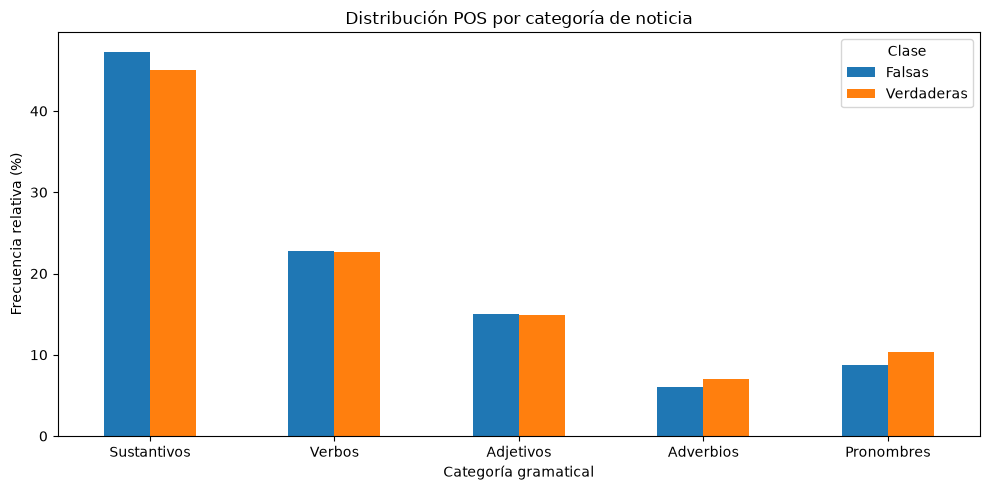

In [40]:
paths_pos = save_pos_results(pos_counts, word_counts, RESULTS_POS_DIR)
paths_pos

### Interpretación inicial

La tabla y el gráfico permiten comparar la proporción de cada categoría respecto del total de tokens de las cinco categorías analizadas en cada clase. Si se dividiera entre todos los tokens del corpus, las proporciones no sumarían 100% porque se omitirían otras etiquetas POS, como determinantes, artículos, adposiciones y conjunciones. Las diferencias deben interpretarse junto con la longitud y el tema de las noticias: una mayor frecuencia relativa no demuestra por sí sola que una categoría gramatical sea un indicador suficiente de falsedad.

## 4. Reconocimiento de Entidades Nombradas (NER)

Se extraen las entidades reconocidas por spaCy sobre el texto crudo. Cada fila representa una menci?n y conserva el documento, la clase, el texto de la entidad y su tipo. Las repeticiones se mantienen porque son necesarias para calcular frecuencias.

In [41]:
from src.pos_ner import (
    extract_entities,
    summarize_entities,
    entity_type_distribution,
    top_global_entities,
    plot_ner_distribution,
    plot_top_entities,
    save_ner_results,
)

ner_entities = extract_entities(metadata, nlp, text_column="text", label_column="label")
ner_summaries = summarize_entities(ner_entities, top_n=10)

print(f"Menciones detectadas: {len(ner_entities):,}")
print(f"Documentos con entidades: {ner_entities['doc_id'].nunique():,}")
display(ner_entities.head())

Menciones detectadas: 50,648
Documentos con entidades: 5,286


,doc_id,label,clase,entidad,tipo
0,ds_falso_0001,0,Falsas,Gobierno andaluz,LOC
1,ds_falso_0001,0,Falsas,Junta,MISC
2,ds_falso_0001,0,Falsas,Consejería de Agricultura,LOC
3,ds_falso_0001,0,Falsas,Carmen Crespo,PER
4,ds_falso_0001,0,Falsas,BNG,ORG


In [42]:
# Total de entidades y distribuci?n porcentual por tipo dentro de cada clase.
ner_by_class = ner_summaries["by_class"]
ner_type_distribution = entity_type_distribution(ner_entities)
display(ner_by_class)
display(ner_type_distribution)

,label,clase,menciones,entidades_unicas,documentos
0,0,Falsas,24207,8025,2646
1,1,Verdaderas,26441,9994,2640


,label,clase,tipo,menciones,documentos,porcentaje
0,0,Falsas,LOC,7643,2084,31.573512
1,0,Falsas,PER,6091,2242,25.162143
2,0,Falsas,MISC,5690,2041,23.505598
3,0,Falsas,ORG,4783,1867,19.758747
4,1,Verdaderas,LOC,8765,2072,33.149276
5,1,Verdaderas,MISC,6651,2015,25.154117
6,1,Verdaderas,PER,6617,1878,25.025529
7,1,Verdaderas,ORG,4408,1733,16.671079


In [43]:
# Diez entidades más frecuentes por tipo para cada clase.
ner_top_by_type = ner_summaries["top_entities"]
display(ner_top_by_type[ner_top_by_type["label"] == 1])
display(ner_top_by_type[ner_top_by_type["label"] == 0])

,label,clase,tipo,entidad,frecuencia
40,1,Verdaderas,LOC,Gobierno,343
41,1,Verdaderas,LOC,EE.UU.,245
42,1,Verdaderas,LOC,Venezuela,245
43,1,Verdaderas,LOC,Colombia,160
44,1,Verdaderas,LOC,Estados Unidos,151
45,1,Verdaderas,LOC,Madrid,149
46,1,Verdaderas,LOC,Estado,136
47,1,Verdaderas,LOC,Reino Unido,96
48,1,Verdaderas,LOC,Cuba,92
49,1,Verdaderas,LOC,Argentina,88


,label,clase,tipo,entidad,frecuencia
0,0,Falsas,LOC,Ceuta,619
1,0,Falsas,LOC,Gobierno,506
2,0,Falsas,LOC,Marruecos,236
3,0,Falsas,LOC,Madrid,216
4,0,Falsas,LOC,Coalición Canaria,205
5,0,Falsas,LOC,España,190
6,0,Falsas,LOC,Nueva Canarias,184
7,0,Falsas,LOC,Qué,126
8,0,Falsas,LOC,Melilla,96
9,0,Falsas,LOC,Comunidad de Madrid,92


In [44]:
# Veinte entidades m?s frecuentes globalmente por categor?a.
ner_top_true = top_global_entities(ner_entities, label=1, n=20)
ner_top_false = top_global_entities(ner_entities, label=0, n=20)
display(ner_top_true)
display(ner_top_false)

,label,clase,entidad,frecuencia
0,1,Verdaderas,PP,590
1,1,Verdaderas,Gobierno,394
2,1,Verdaderas,PSOE,330
3,1,Verdaderas,EE.UU.,245
4,1,Verdaderas,Venezuela,245
5,1,Verdaderas,Vox,231
6,1,Verdaderas,Congreso,181
7,1,Verdaderas,España,178
8,1,Verdaderas,También,174
9,1,Verdaderas,Colombia,160


,label,clase,entidad,frecuencia
0,0,Falsas,Ceuta,619
1,0,Falsas,Gobierno,566
2,0,Falsas,Iniciativa vers per Catalunya,474
3,0,Falsas,España,393
4,0,Falsas,PP,310
5,0,Falsas,BNG,279
6,0,Falsas,Cristina Narbona,245
7,0,Falsas,Congreso,237
8,0,Falsas,EQUO,236
9,0,Falsas,Marruecos,236


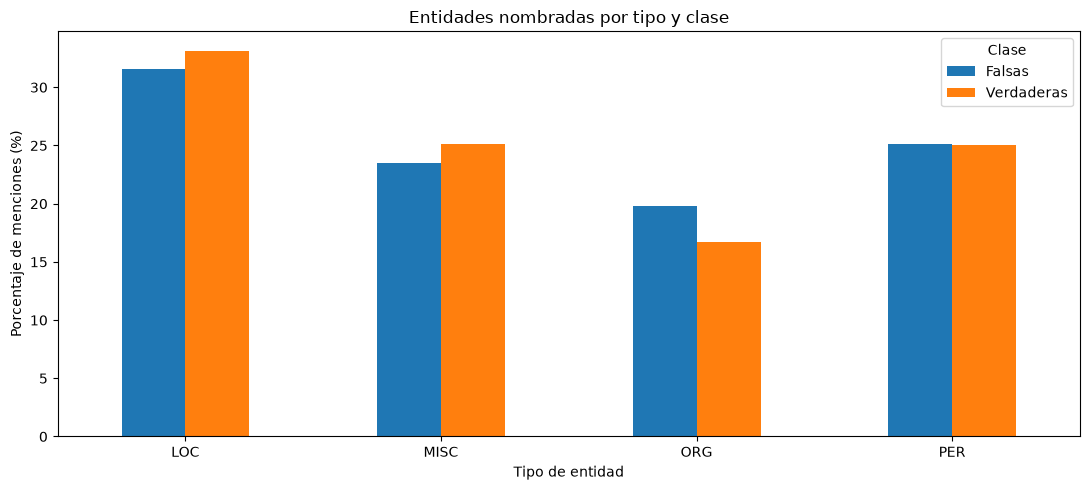

In [45]:
import matplotlib.pyplot as plt

RESULTS_NER_DIR = ROOT / "results" / "ner"
RESULTS_NER_DIR.mkdir(parents=True, exist_ok=True)

ner_distribution_figure = plot_ner_distribution(ner_entities)
display(ner_distribution_figure)
ner_distribution_figure.savefig(RESULTS_NER_DIR / "ner_distribution.png", dpi=160, bbox_inches="tight")
plt.close(ner_distribution_figure)

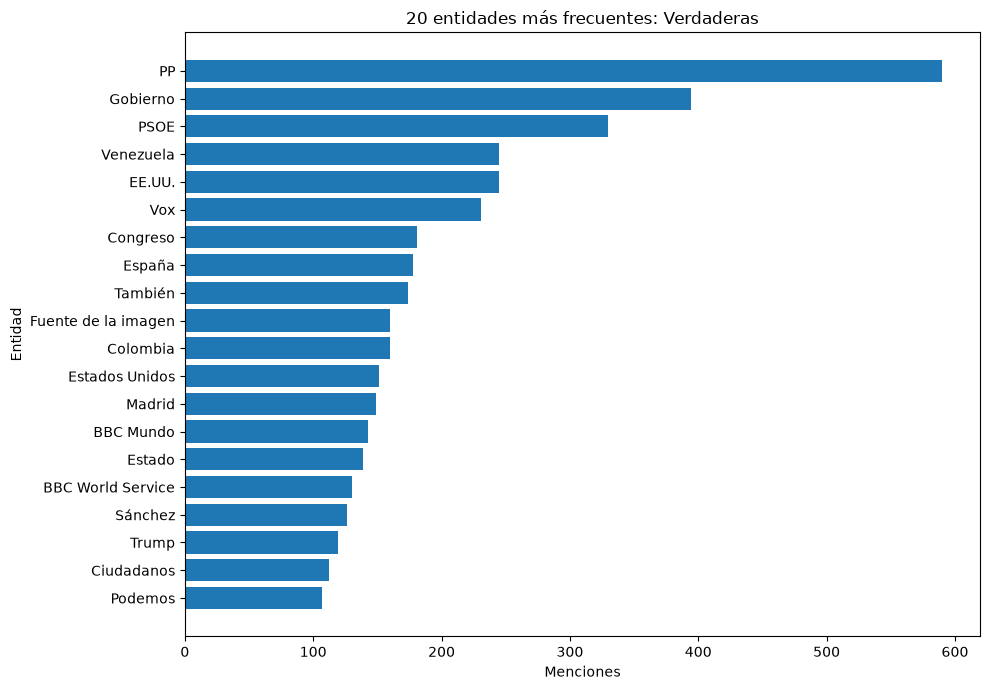

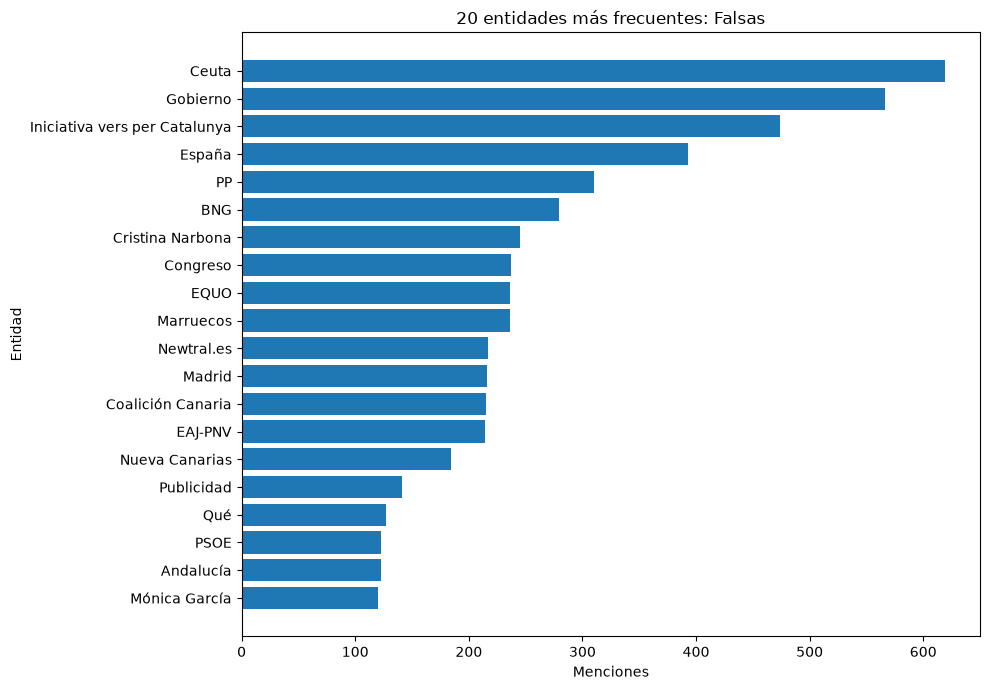

In [46]:
true_figure = plot_top_entities(ner_entities, label=1, n=20)
false_figure = plot_top_entities(ner_entities, label=0, n=20)
display(true_figure)
display(false_figure)
true_figure.savefig(RESULTS_NER_DIR / "ner_top_verdaderas.png", dpi=160, bbox_inches="tight")
false_figure.savefig(RESULTS_NER_DIR / "ner_top_falsas.png", dpi=160, bbox_inches="tight")
plt.close(true_figure)
plt.close(false_figure)

{'entities': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_entities.csv'),
 'summary': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_summary.csv'),
 'by_type': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_by_type.csv'),
 'top_entities': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_top_entities.csv'),
 'by_class': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_by_class.csv'),
 'type_distribution': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_type_distribution.csv'),
 'top_global_true': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_top_global_verdaderas.csv'),
 'top_global_false': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_top_global_falsas.csv'

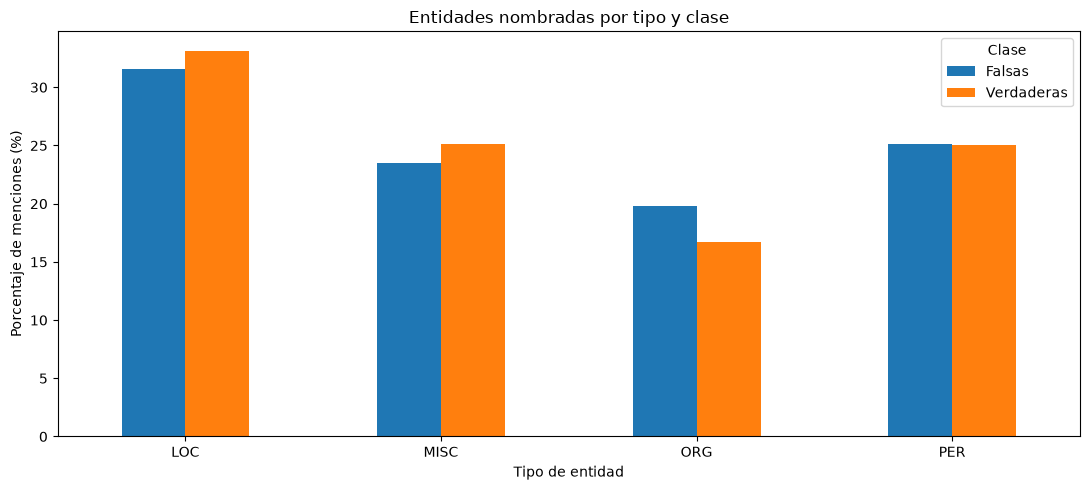

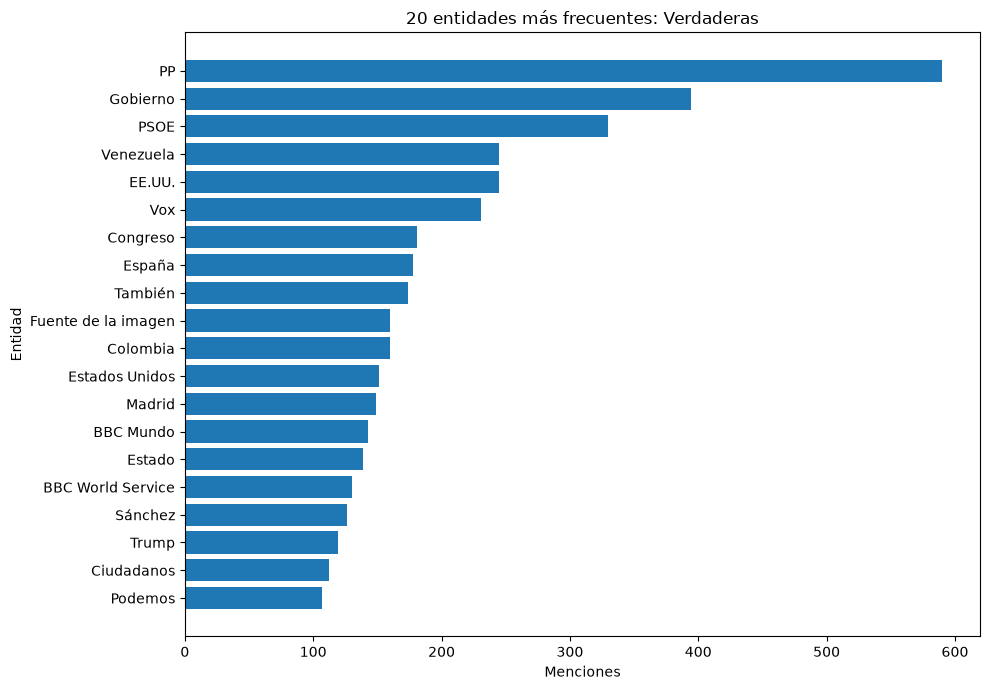

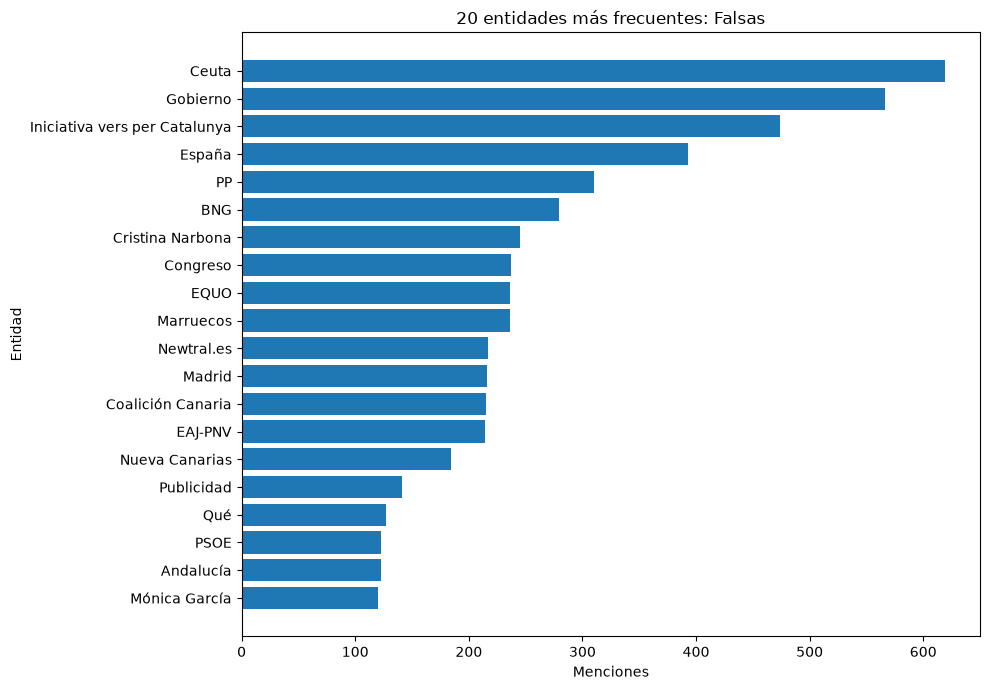

In [47]:
ner_paths = save_ner_results(ner_entities, RESULTS_NER_DIR, top_n=10)
ner_paths

### Revisi?n de errores del modelo

Las predicciones de NER no incluyen una anotaci?n de referencia en el corpus, por lo que los errores deben validarse manualmente. Para el informe se deben seleccionar al menos cinco casos de `ner_entities` y documentar si son falsos positivos, categor?as incorrectas o entidades omitidas. La revisi?n debe incluir el fragmento original, la predicci?n del modelo, la categor?a esperada y la justificaci?n.

## 5. Extracción de características

En esta sección se usarán unigramas, bigramas, stopwords, stemming, términos de ocurrencia y TF-IDF mediante `src/features.py`.

In [52]:
from src.features import preprocess_for_features, extract_features

# 1. Aplicar stopwords y stemming (con las banderas activas por defecto)
print("Aplicando Stopwords y Stemming (esto puede tomar unos segundos)...")
processed = preprocess_for_features(
    processed, 
    text_column='clean_text', 
    output_column='text_stemmed',
    apply_stopwords=True, 
    apply_stemming=True
)

# Ver el antes y el después
processed[['clean_text', 'text_stemmed']].head()

Aplicando Stopwords y Stemming (esto puede tomar unos segundos)...


,clean_text,text_stemmed
0,el organo que fiscaliza al gobierno andaluz de...,organ fiscaliz gobiern andaluz defiend legal n...
1,pp pide a cristina narbona igualar los permiso...,pp pid cristin narbon igual permis patern mate...
2,cristina narbona rebaja las hipotesis electora...,cristin narbon rebaj hipotesis electoral abal ...
3,carrero blanco elegida candidata del iniciativ...,carrer blanc eleg candidat inici vers per cata...
4,diego canamero pide aprobar ya los presupuesto...,dieg canamer pid aprob presupuest catalan pali...


In [53]:
# 2. Extracción de características con Unigramas y Bigramas (Frecuencia < 3 eliminada)
print("Extrayendo características (BoW)...")

# Utilizando method='bow' para cumplir estrictamente con el requerimiento de Bolsa de Palabras
X_features, vectorizer = extract_features(
    processed, 
    text_column='text_stemmed', 
    method='bow', 
    min_freq=3
)

print(f"Matriz de características creada con éxito.")
print(f"Número de documentos: {X_features.shape[0]}")
print(f"Total de características (unigramas y bigramas válidos): {X_features.shape[1]}")

Extrayendo características (BoW)...
Matriz de características creada con éxito.
Número de documentos: 5300
Total de características (unigramas y bigramas válidos): 17151


In [54]:
# 3. Mostrar una muestra de las características extraídas (Unigramas y Bigramas)
feature_names = vectorizer.get_feature_names_out()

print("Muestra de unigramas y bigramas extraídos:")
print(feature_names[1000:1010]) # Imprime 10 tokens de ejemplo

Muestra de unigramas y bigramas extraídos:
['anunci med' 'anunci mism' 'anunci moment' 'anunci nuev' 'anunci paquet'
 'anunci part' 'anunci pas' 'anunci plan' 'anunci present'
 'anunci president']


## 6. Modelado de temas

En esta sección se ejecutarán LSA, LDA y las métricas de coherencia mediante `src/topics.py`.

In [56]:
from src.features import extract_features

print("PUNTO 6: Ponderación de Características\n" + "-"*40)

# 1. Frecuencia Absoluta (Term Occurrences - TO)
print("Generando ponderación por Frecuencia Absoluta (TO)...")
X_to, vectorizer_to = extract_features(processed, text_column='text_stemmed', method='bow', min_freq=3)

# 2. Esquema TF-IDF
print("Generando ponderación por TF-IDF...")
X_tfidf, vectorizer_tfidf = extract_features(processed, text_column='text_stemmed', method='tfidf', min_freq=3)

print(f"\nDimensiones de la matriz TO (BoW): {X_to.shape}")
print(f"Dimensiones de la matriz TF-IDF: {X_tfidf.shape}")

PUNTO 6: Ponderación de Características
----------------------------------------
Generando ponderación por Frecuencia Absoluta (TO)...
Generando ponderación por TF-IDF...

Dimensiones de la matriz TO (BoW): (5300, 17151)
Dimensiones de la matriz TF-IDF: (5300, 17151)


In [57]:
from src.topics import get_lsa_topics, get_lda_topics

# Número de tópicos a extraer y palabras a mostrar
N_TOPICS = 5
N_WORDS = 8

# A. Ejecutar LSA (Se alimenta con TF-IDF)
print("--- TÓPICOS CON LSA (Aplicado sobre TF-IDF) ---")
lsa_model, lsa_matrix, lsa_topics = get_lsa_topics(X_tfidf, vectorizer_tfidf, n_topics=N_TOPICS, n_words=N_WORDS)

for i, topic in enumerate(lsa_topics):
    print(f"Tópico {i+1}: {', '.join(topic)}")

# B. Ejecutar LDA (Se alimenta con Frecuencia Absoluta / TO)
print("\n--- TÓPICOS CON LDA (Aplicado sobre Frecuencia Absoluta) ---")
lda_model, lda_matrix, lda_topics = get_lda_topics(X_to, vectorizer_to, n_topics=N_TOPICS, n_words=N_WORDS)

for i, topic in enumerate(lda_topics):
    print(f"Tópico {i+1}: {', '.join(topic)}")

--- TÓPICOS CON LSA (Aplicado sobre TF-IDF) ---
Tópico 1: cataluny, per, inici, vers per, inici vers, per cataluny, vers, gobiern
Tópico 2: vers per, inici vers, per cataluny, vers, per, inici, cataluny, equ
Tópico 3: pnv, eaj pnv, eaj, canari, nuev canari, vot, bng, coalicion
Tópico 4: eaj pnv, eaj, pnv, canari, nuev canari, nuev, bng, unid eaj
Tópico 5: madr, juez, tribunal, suprem, conden, cas, investig, pabl

--- TÓPICOS CON LDA (Aplicado sobre Frecuencia Absoluta) ---
Tópico 1: public, mas, ceut, pais, si, person, tambi, vide
Tópico 2: gobiern, pp, part, ley, congres, nuev, vot, pso
Tópico 3: president, madr, gobiern, polit, mas, ser, nuev, bng
Tópico 4: mas, terremot, bbc, cas, colombi, nuev, tambi, anos
Tópico 5: cataluny, inici, per, vers, per cataluny, vers per, inici vers, gobiern


## 7. Clasificación

En esta sección se compararán cuatro algoritmos y ocho configuraciones usando validación cruzada mediante `src/classify.py`.

A diferencia de las etapas anteriores, el modelado de temas es no supervisado. Para no establecer el número de temas ($k$) de forma arbitraria, primero calcularemos el **Score de Coherencia** para diferentes valores de $k$ (Paso 7.3). Una vez elegido el mejor $k$, lo aplicaremos en LSA y LDA.

In [58]:
from src.topic_modeling import (
    prepare_gensim_corpus, 
    calculate_coherence_values, 
    plot_coherence, 
    run_lsa, 
    run_lda
)

# Preparar los textos extraídos en la sección de preprocesamiento
textos_limpios = processed["clean_text"].tolist()

# Preparar el corpus y diccionario para Gensim (se usarán en LDA y Coherencia)
dictionary, corpus, tokenized_texts = prepare_gensim_corpus(textos_limpios)

Calculamos la coherencia para $k$ entre 2 y 10 utilizando LDA.

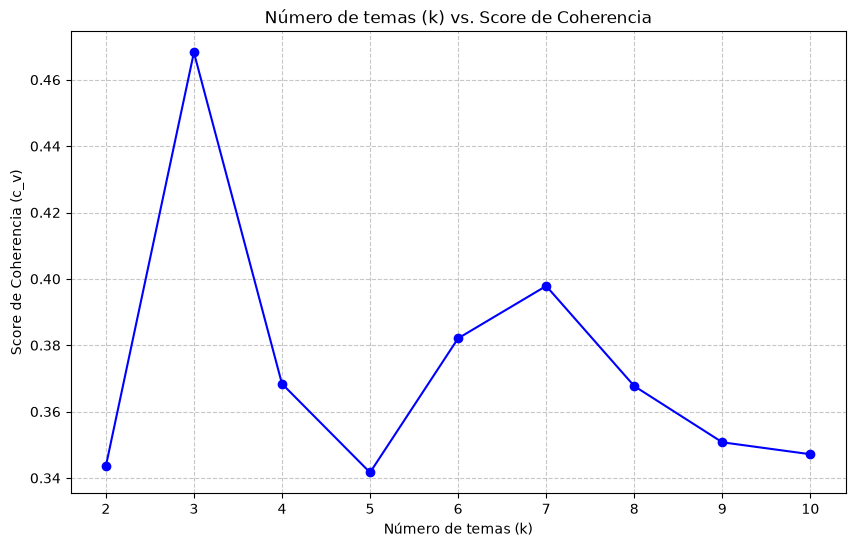

In [59]:
# Calcular valores de coherencia para k de 2 a 10
inicio, limite, paso = 2, 10, 1
coherence_scores = calculate_coherence_values(
    dictionary=dictionary, 
    corpus=corpus, 
    texts=tokenized_texts, 
    start=inicio, 
    limit=limite, 
    step=paso
)

# Generar la gráfica
plot_coherence(inicio, limite, paso, coherence_scores)

**Justificación del número de temas ($3$):**
Para los siguientes apartados definiremos `k_optimo = 3`

In [60]:
k_optimo = 3

### 7.1 Latent Semantic Analysis (LSA)

Aplicamos TF-IDF y SVD para extraer los temas.

In [61]:
lsa_model, vectorizer, lsa_topics = run_lsa(textos_limpios, num_topics=k_optimo, top_n=10)

print(f"Top 10 palabras por tema usando LSA (k={k_optimo}):\n")
for tema, palabras in lsa_topics.items():
    print(f"{tema}: {', '.join(palabras)}")

Top 10 palabras por tema usando LSA (k=3):

Tema 1: catalunya, per, iniciativa, vers, gobierno, equo, pp, madrid, partido, coalicion
Tema 2: vers, per, iniciativa, catalunya, equo, boluarte, canaria, coalicion, riba, diana
Tema 3: pnv, pp, eaj, equo, psoe, unidas, partido, coalicion, andalucia, canarias


**Interpretación manual de los temas (LSA):**
* **Tema 1 (Política nacional y conflicto territorial):** Agrupa términos relacionados con la política española, enfocándose en la relación y tensión entre el gobierno central y Cataluña (*catalunya, gobierno, madrid, pp*), así como alianzas y partidos políticos (*iniciativa, equo, partido, coalición*).
* **Tema 2 (Coaliciones regionales e izquierda):** Muy similar al Tema 1, pero más enfocado en coaliciones y formaciones de izquierda/verdes y nombres propios, con la fuerte presencia repetida de la agrupación "Iniciativa per Catalunya Verds" (*vers, per, iniciativa, catalunya, equo, coalicion*) y figuras políticas específicas (*diana riba, boluarte*).
* **Tema 3 (Partidos políticos y regionalismo):** Claramente enfocado en el panorama de partidos nacionales y nacionalistas de distintas comunidades autónomas (*pnv, eaj, psoe, unidas, pp, andalucia, canarias*).

### 7.2 Latent Dirichlet Allocation (LDA)

Aplicamos LDA utilizando Bag of Words y Gensim con el mismo número de temas.

In [62]:
lda_model, lda_topics = run_lda(corpus, dictionary, num_topics=k_optimo, top_n=10)

print(f"Top 10 palabras por tema usando LDA (k={k_optimo}):\n")
for tema, palabras in lda_topics.items():
    print(f"{tema}: {', '.join(palabras)}")

Top 10 palabras por tema usando LDA (k=3):

Tema 1: pais, anos, bbc, mundo, gobierno, venezuela, imagen, personas, fuente, colombia
Tema 2: ceuta, publicidad, video, personas, redes, caso, marruecos, newtral, imagenes, sociales
Tema 3: gobierno, partido, presidente, catalunya, congreso, sanchez, psoe, madrid, ley, iniciativa


**Interpretación manual de los temas (LDA):**
* **Tema 1 (Noticias internacionales y Latinoamérica):** Relacionado con el periodismo internacional, específicamente noticias de la BBC Mundo sobre países latinoamericanos (*bbc, mundo, venezuela, colombia, pais*).
* **Tema 2 (Desinformación, redes sociales y crisis migratoria):** Agrupa claramente vocabulario de *fact-checking* y redes (*video, redes, sociales, newtral, imagenes, publicidad*), muy vinculado a la crisis fronteriza (*ceuta, marruecos*). 
* **Tema 3 (Política interior española y legislativo):** Enfocado en el gobierno de España, el Congreso y la actividad legislativa (*gobierno, presidente, sanchez, congreso, psoe, madrid, ley*).

**Conclusión del Modelado de Temas:**
Al comparar ambos modelos, **LDA ha generado temas mucho más coherentes, distintos y fáciles de interpretar que LSA**. Mientras que LSA sufre de solapamiento (repite fragmentos como "iniciativa per catalunya vers" en varios temas) y agrupa casi todo bajo "partidos políticos", LDA logra separar limpiamente el corpus en tres categorías lógicas: (1) Noticias internacionales (BBC), (2) Fact-checking de redes sociales y migración (Newtral), y (3) Política interior española (Sánchez, Congreso).

## 8. ANÁLISIS DE TEMAS SEGÚN LA VERACIDAD DE LAS NOTICIAS 

Se determina el tema dominante para cada documento a partir del modelo de temas seleccionado. Posteriormente, se evalúa la distribución porcentual de los temas entre noticias verdaderas (`label=1`) y falsas (`label=0`).

In [72]:
import pandas as pd
import numpy as np
from src.topic_analysis import (
    get_dominant_topic,
    compute_topic_distribution_table,
    plot_topic_comparison,
)

# 1. Asignar las etiquetas de tu LDA (k=3)
topic_labels = {
    0: "Internacional y LATAM",
    1: "Desinformación y Redes Sociales",
    2: "Política Interior Española"
}

# 2. Construir la matriz documento-tema (doc_topic_matrix) usando Gensim
num_docs = len(corpus)
k = 3
doc_topic_matrix = np.zeros((num_docs, k))

for i, doc_bow in enumerate(corpus):
    # lda_model[doc_bow] devuelve tuplas con la estructura (ID_tema, probabilidad)
    for topic_id, prob in lda_model[doc_bow]:
        doc_topic_matrix[i, topic_id] = prob

# 3. Asignar el tema dominante a tu dataframe (sobrescribe la columna anterior)
processed["dominant_topic"] = get_dominant_topic(
    doc_topic_matrix, topic_labels=topic_labels
)

# 4. Construir y mostrar la tabla comparativa
topic_table = compute_topic_distribution_table(
    processed, topic_column="dominant_topic", label_column="label"
)

topic_table

,Tema,Verdaderas (cantidad),Verdaderas (%),Falsas (cantidad),Falsas (%)
0,Desinformación y Redes Sociales,550,20.75,427,16.11
1,Internacional y LATAM,304,11.47,127,4.79
2,Política Interior Española,1796,67.77,2096,79.09


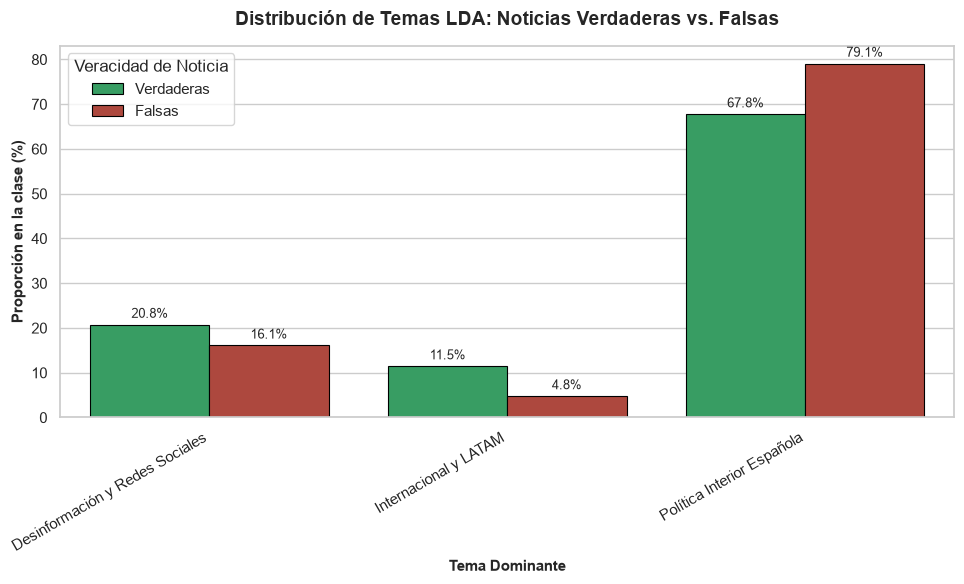

In [73]:
plot_topic_comparison(
    topic_table,
    title="Distribución de Temas LDA: Noticias Verdaderas vs. Falsas",
)

### Análisis de la distribución temática según la veracidad de las noticias

Al cruzar los datos cuantitativos obtenidos con la interpretación cualitativa del modelo LDA (k=3) establecida en el Punto 7, se confirman las siguientes dinámicas entre la temática y la veracidad del contenido:

1. **Política Interior Española (Tema Transversal / Eje de Desinformación):**
   * **Resultados:** Es el tema dominante en ambas clases, pero representa un **79.09% (2,096 noticias)** de las noticias falsas frente a un **67.77% (1,796 noticias)** de las verdaderas.
   Se valida la hipótesis de que la política nacional (gobierno, Congreso, partidos) es un tema transversal y polarizante. Funciona como la base del periodismo diario legítimo, pero al mismo tiempo es el principal vector para la creación de narrativas manipuladas, ataques políticos y falsedades.

2. **Internacional y LATAM (Periodismo Internacional Estructurado):**
   * **Resultados:** Registra un **11.47% (304 noticias)** en las noticias verdaderas, mientras que solo alcanza un **4.79% (127 noticias)** en las falsas (más del doble de presencia proporcional en contenido real).
   Confirma que este grupo responde al formato clásico de noticias reportadas por medios internacionales formales (como BBC Mundo). El periodismo internacional utiliza un lenguaje estructurado con fuentes confiables, donde la circulación de noticias falsas es significativamente menor en la muestra.

3. **Desinformación y Redes Sociales (Ecosistema Viral y Fact-checking):**
   * **Resultados:** Concentra un **20.75% (550 noticias)** en la clase verdadera frente a un **16.11% (427 noticias)** en la falsa.
    Refleja la doble naturaleza de este léxico (*video, redes, sociales, newtral*). Por un lado, engloba el contenido engañoso difundido de forma viral en plataformas digitales; por otro lado, está fuertemente presente en los artículos de verificación (*fact-checking* de agencias como Newtral), los cuales analizan y desmienten falsedades citando explícitamente las fuentes y redes de origen, registrándose metodológicamente como artículos verdaderos.


### Conclusión

 La **política interior** es el principal terreno de confrontación donde se concentran las noticias falsas, mientras que el **periodismo internacional** destaca por su alto nivel de veracidad. Por su parte, la presencia del ecosistema de **redes sociales** evidencia la labor activa de las plataformas de verificación frente a la desinformación viral.